# Laboratoriska vezba #1
# Binarna klasifikacija na gama zracenja!!!!!!!!

In [96]:
import matplotlib.pyplot as plt #Libraries for visualization
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import seaborn as sns
import numpy as np #Library for numerical calculations
from scipy import stats #Library for statistical analysis 
from sklearn import datasets #Libraries for machine learning
from sklearn.naive_bayes import GaussianNB 
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 
import pandas as pd
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from ucimlrepo import fetch_ucirepo 

In [97]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
# data (as pandas dataframes) 
x = magic_gamma_telescope.data.features 
y = magic_gamma_telescope.data.targets 



numberFeatures = x.shape[1]  
numberClasses = len(np.unique(y))







In [119]:
features = x.values
classes = y['class'].values
klasi = [0 if e == 'g'else 1 for e in classes]

feature_names = x.columns.tolist()
df = magic_gamma_telescope.data.original
print('Feature names:', feature_names)
print('Class names:  ', ['gamma', 'hardon'])

Feature names: ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist']
Class names:   ['gamma', 'hardon']


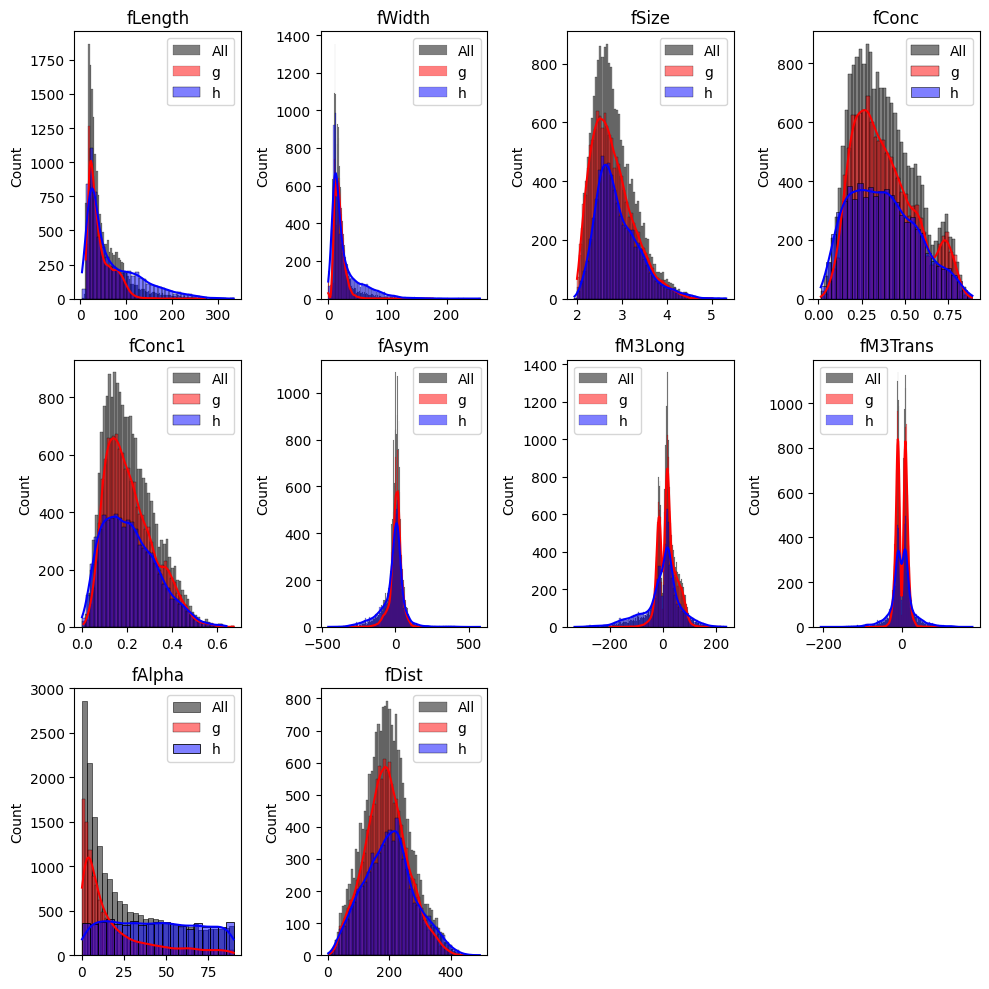

In [99]:
colors = ['red', 'blue']
fig = plt.figure(figsize=(10, 10))
fig.subplots_adjust(hspace=0.4)  # Space subplots

maps = {0:'g', 1:'h'}
for feature in range(numberFeatures):
    ax = plt.subplot(3, 4, feature+1)
    plt.title(feature_names[feature])
    
    # All classes (grey, transparent)
    sns.histplot(features[:, feature], color='black', label='All', kde=False, alpha=0.5)
    
    # Per class with unique labels/colors, transparency
    for Class in range(numberClasses):
        mask = np.array(klasi) == Class
        
        sns.histplot(features[mask, feature], color=colors[Class], 
                     kde=True, label=maps[Class])
    
    plt.legend()
plt.tight_layout()
plt.show()


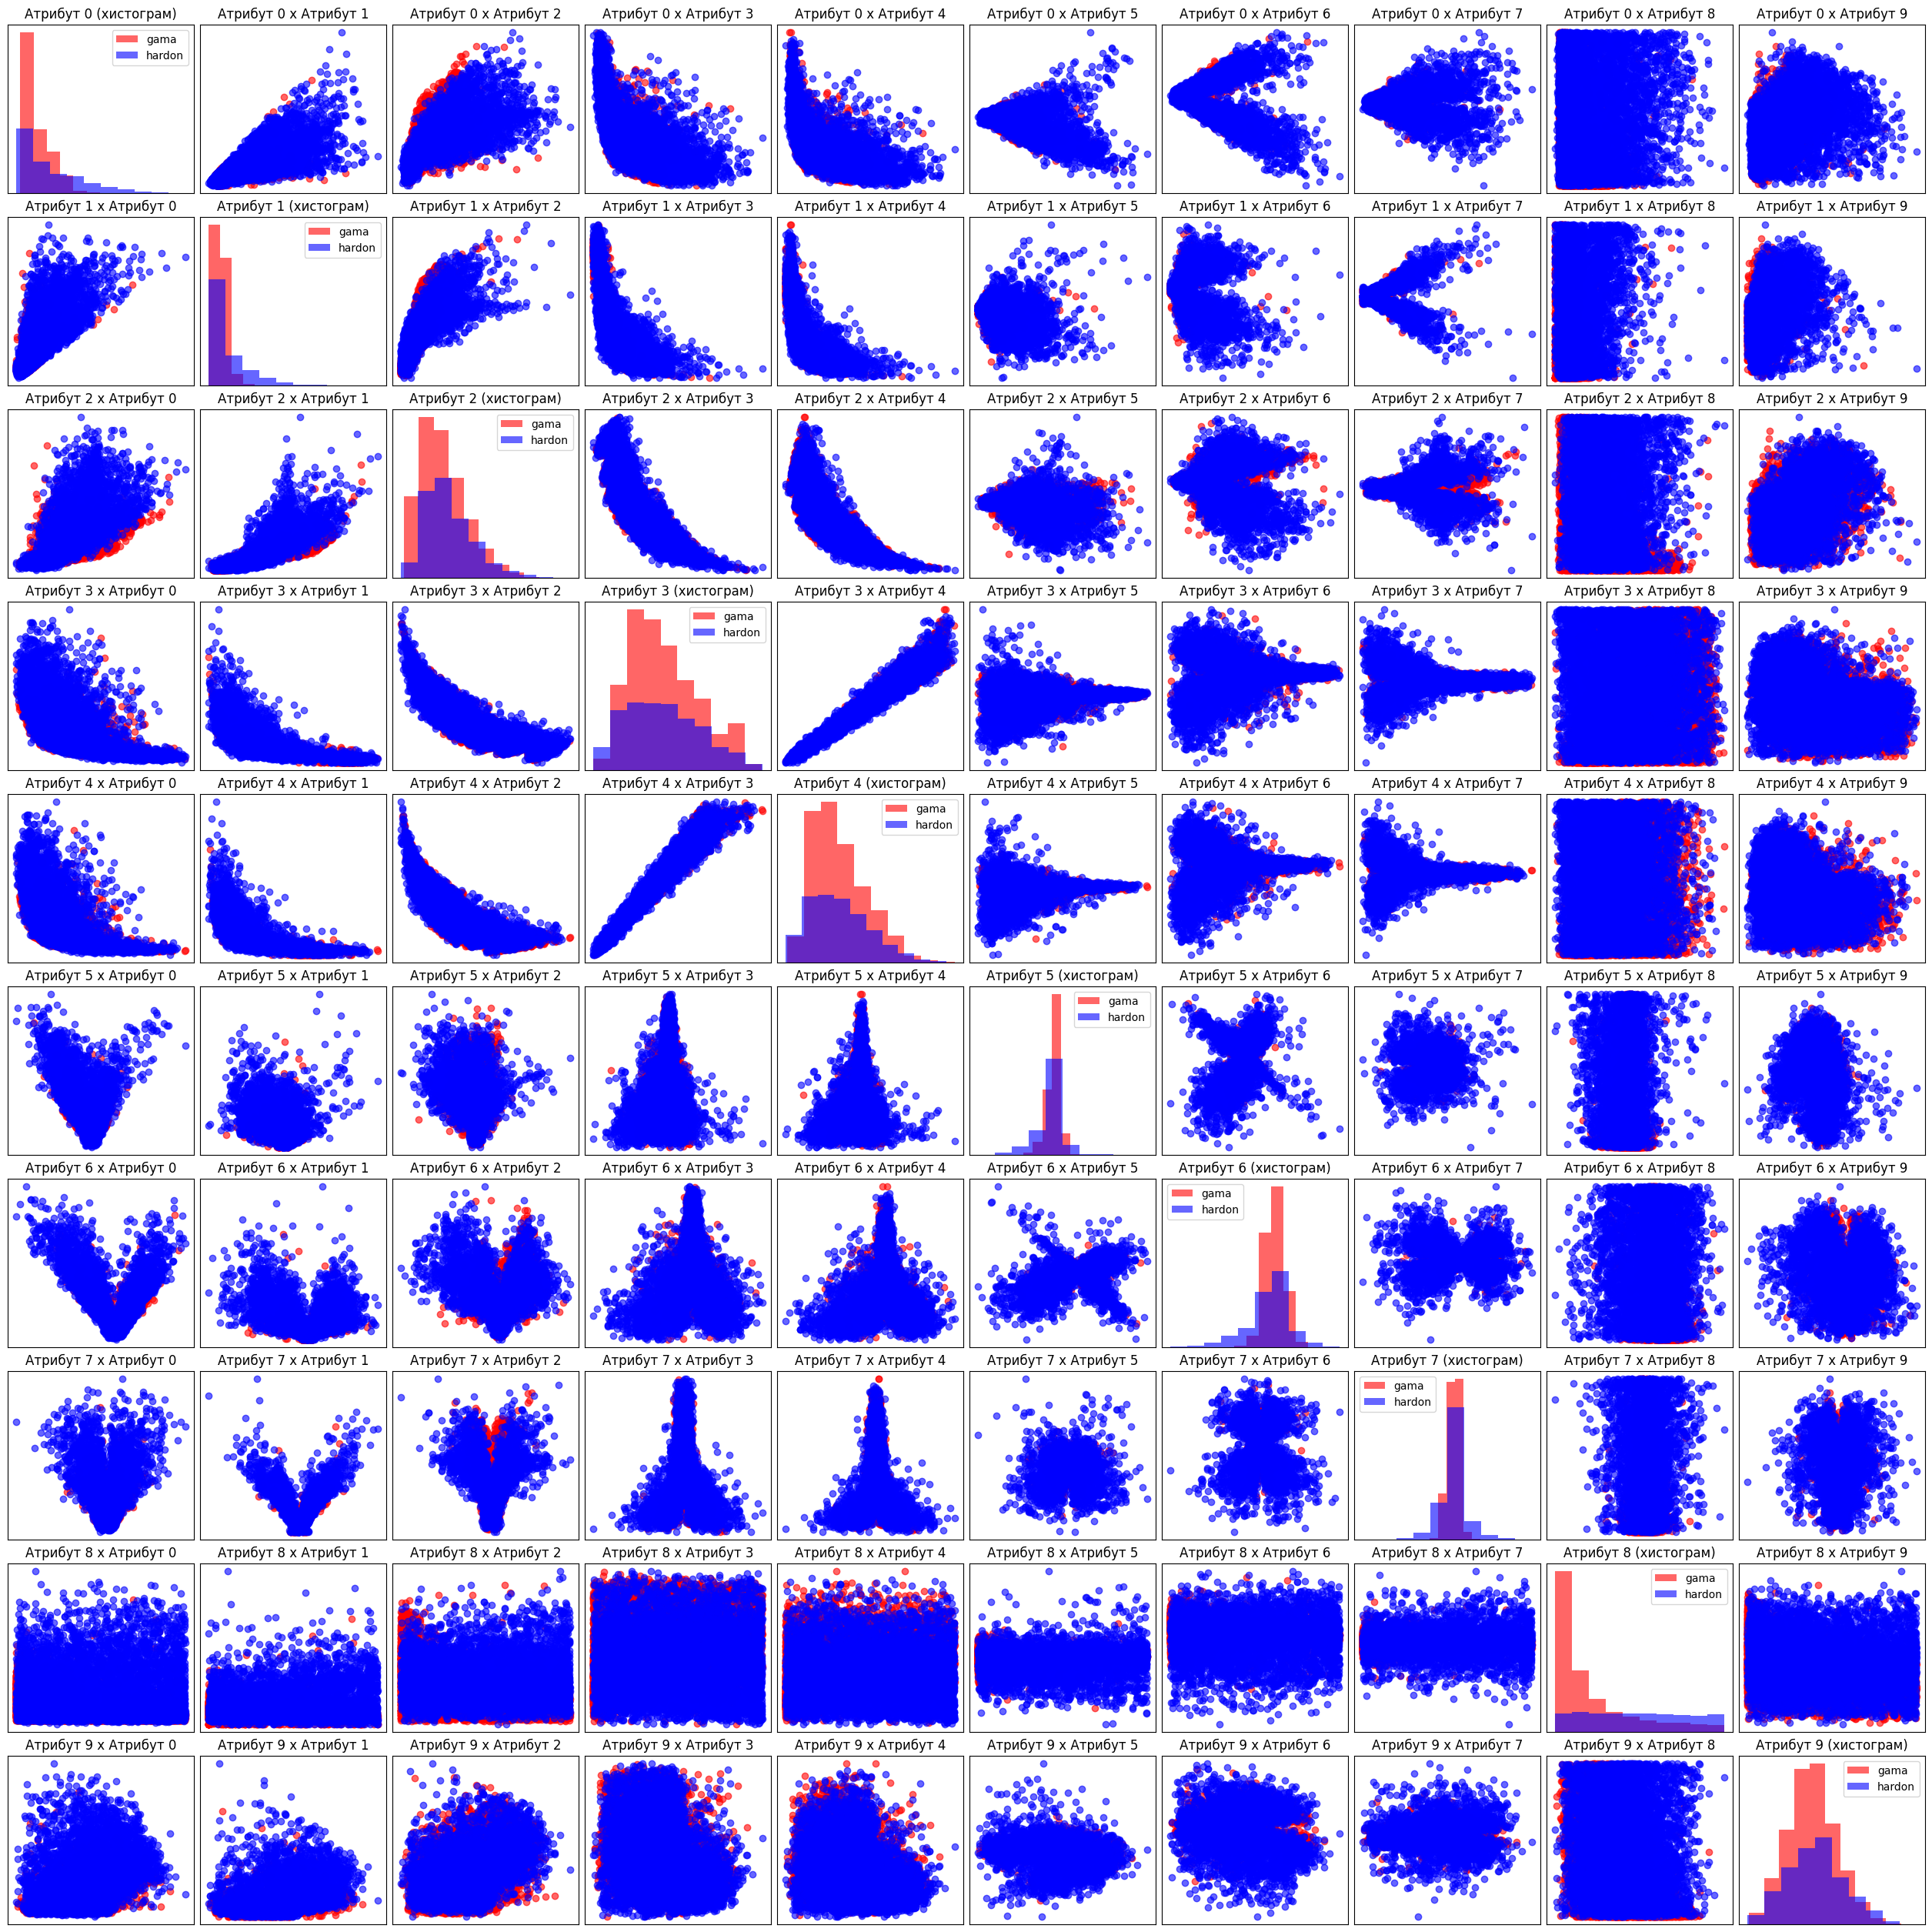

In [100]:
number_of_features = numberFeatures
X = features
target_names = ['gama', 'hardon']
fig = plt.figure(figsize=(25, 25),layout='constrained')
fig.subplots(nrows=number_of_features, ncols=number_of_features)
#int(number_of_features/4)

for feature_i in range(number_of_features):
    for feature_j in range(number_of_features):  
        ax = plt.subplot(number_of_features,number_of_features,number_of_features*feature_i + feature_j+1)
        if feature_i==feature_j:
            for color, i, target_name in zip(colors, [0, 1], target_names):
                mask = np.array(klasi) == i
                plt.hist(X[mask, feature_i], alpha=.6, color=color, label=target_name)
            plt.title("Атрибут "+str(feature_i)+" (хистограм)")
            plt.legend()
        else:
            for color, i, target_name in zip(colors, [0, 1], target_names):
                mask = np.array(klasi) == i
                plt.scatter(X[mask, feature_i], X[mask, feature_j], alpha=.6, color=color, label=target_name)
            plt.title("Атрибут "+str(feature_i)+" x Атрибут "+str(feature_j))
        plt.xticks(())
        plt.yticks(())
plt.show()






# Merki za zavisnost

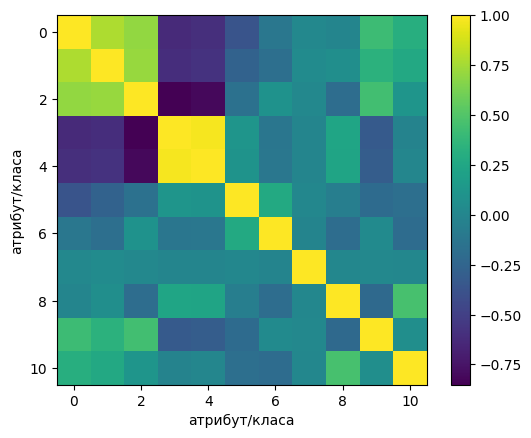

In [101]:
#mask = np.array(klassi) == c


correlation_matrix = np.zeros((number_of_features+1,number_of_features+1))
for feature_i in range(number_of_features): 
    for feature_j in range(number_of_features):
        corr, _ = stats.pearsonr(X[:,feature_i], X[:,feature_j])
        correlation_matrix[feature_i][feature_j] = corr


for feature_i in range(number_of_features): 
    target_i = number_of_features
    corr, _ = stats.pearsonr(X[:,feature_i], klasi)
    correlation_matrix[feature_i][target_i] = corr
    correlation_matrix[target_i][feature_i] = corr

corr, _ = stats.pearsonr(klasi, klasi)
correlation_matrix[target_i][target_i] = corr 
corr, _ = stats.pearsonr(X[:,feature_i], klasi)

plt.figure()
plt.imshow(correlation_matrix)
plt.xlabel("атрибут/класа")
plt.ylabel("атрибут/класа")
plt.colorbar()
plt.show()





# Namaluvanje dimenzionalnost

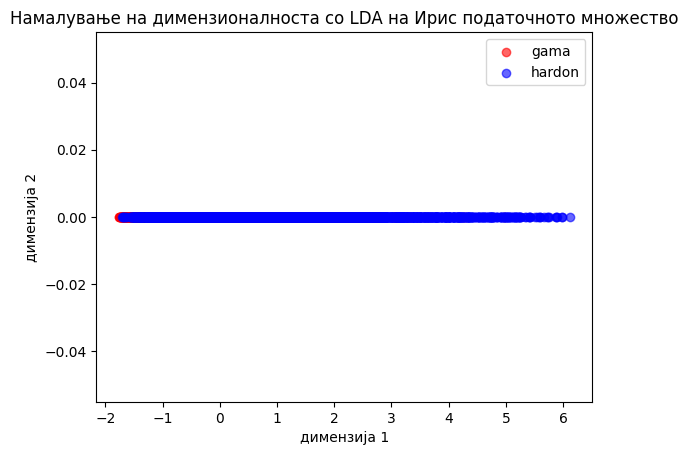

In [102]:
LDA_reduce = LinearDiscriminantAnalysis(n_components=1 ) # Го поставуваме бројот ан компоненти во новиот простор на 2 
LDA_reduce.fit(X, klasi) # Го фитуваме LDA моделот на податоците X и y
X_lda_reduced = LDA_reduce.transform(X) # Со помош на фитуваниот модел ги трансформираме влезните податоци X во но новите X_LDA

# Сега можеме да го визуелизираме податочното множество на еден дводимензионален график
plt.figure()

for color, i, target_name in zip(colors, [0, 1], target_names):
    mask = np.array(klasi) == i
    plt.scatter(X_lda_reduced[mask, 0], np.zeros(sum(mask)), alpha=0.6, 
                color=color, label=target_names[i])
plt.legend()
plt.xlabel("димензија 1")
plt.ylabel("димензија 2")
plt.title('Намалување на димензионалноста со LDA на Ирис податочното множество')
plt.show()

# PCA


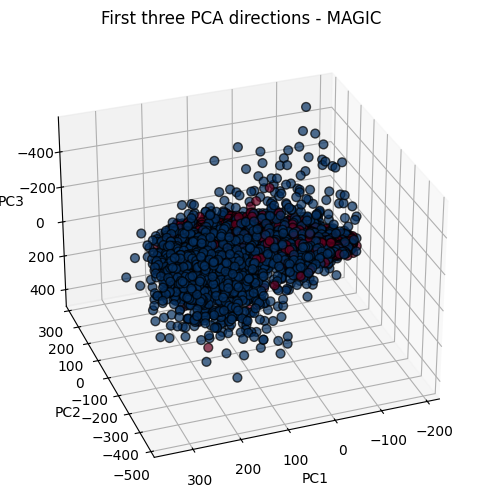

Variance explained: PC1=44.0%, PC2=25.8%, PC3=13.5%


In [111]:
from mpl_toolkits.mplot3d import Axes3D  # Still needed for import

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d', elev=-150, azim=110)  # Fixed!

pca = PCA(n_components=3)
X_pca_reduced = pca.fit(X).transform(X)

scatter = ax.scatter(X_pca_reduced[:, 0], X_pca_reduced[:, 1], X_pca_reduced[:, 2], 
                     c=klasi, cmap='RdBu', edgecolor='k', s=40, alpha=0.7)
ax.set_title("First three PCA directions - MAGIC")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}, PC3={pca.explained_variance_ratio_[2]:.1%}")


# Classification


In [142]:
X_train, X_test, y_train, y_test = train_test_split(X, klasi, test_size=0.30, random_state=42) #We split the original dataset (we use a fixed random state such as 42 so we always split the data the same way)
X_PCA_train, X_PCA_test, y_PCA_train, y_PCA_test = train_test_split(X_pca_reduced, klasi, test_size=0.30, random_state=42) #We split the PCA dimensionaly reducted dataset

X_LDA_train, X_LDA_test, y_LDA_train, y_LDA_test = train_test_split(X_lda_reduced, klasi, test_size=0.30, random_state=42) #We split the LDA dimensionaly reducted dataset

# QuadraticDiscriminantAnalysis


In [105]:
QDA = QuadraticDiscriminantAnalysis() # иницијализација на моделот
QDA.fit(X_train, y_train); # нагодување на моделот на податоците од тренинг множеството
print("Priors:", QDA.priors_)
y_pred = QDA.predict(X_test)
QDA_accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: ", QDA_accuracy)


Priors: [0.64796455 0.35203545]
Accuracy:  0.7854889589905363


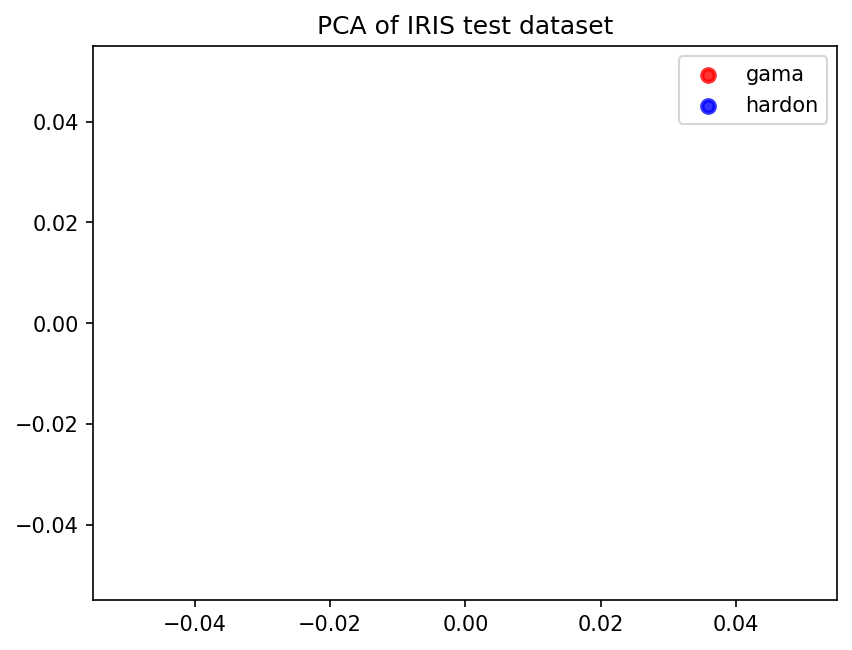

In [177]:
plt.figure() #Here we draw the data in 2D as in the upper image, but we only draw the test data set 
for color, i, target_name in zip(colors, [0, 1], target_names):
    plt.scatter(X_test[y_test == i, 0], X_test[y_test == i, 1], color=color, alpha=.8, lw=2,
                label=target_name)
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA of IRIS test dataset')
plt.show()

# LinearDiscriminantAnalysis

In [106]:
LDA = LinearDiscriminantAnalysis()
LDA.fit(X_train, y_train)
y_pred = LDA.predict(X_test)

LDA_acc = accuracy_score(y_test, y_pred)
print("LDA accuracy: ", LDA_acc)



LDA accuracy:  0.7872415001752541


# GaussianNB

In [113]:
GNB = GaussianNB() # иницијализација на моделот
GNB.fit(X_train, y_train) # нагодување на моделот на податоците од тренинг множеството
y_pred = GNB.predict(X_test) # предвидување на лабелите од тест множеството со користење на нагодениот модел
GNB_acc = accuracy_score(y_test, y_pred) # пресметување на точноста на предвидените лабели од тест множеството

print(GNB_acc)

0.7274798457763757


# PCA data

In [151]:


# Same split + PCA(3)
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Classifier on PCA feats (LDA/NB/RF)
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train_pca, y_train)
y_pred = nb.predict(X_test_pca)

print("PCA(3)+NB Acc:", accuracy_score(y_test, y_pred))

# Raw LDA

pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)  # Fit TRAIN
X_test_pca = pca.transform(X_test)        # Transform TEST

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_pca, y_train)
y_pred = lda.predict(X_test_pca)

# Metrics (ROC key for imbalance!)
print("Acc:", accuracy_score(y_PCA_test, y_pred))

lda = LinearDiscriminantAnalysis(solver="svd", store_covariance=True)
lda.fit(X_LDA_train, y_LDA_train)
y_pred = lda.predict(X_LDA_test)
print(accuracy_score(y_LDA_test, y_pred))








PCA(3)+NB Acc: 0.7089029092183666
Acc: 0.7064493515597616
0.7867157378198387


# Otstraneti features

# Playing with priors

In [170]:
QDA = QuadraticDiscriminantAnalysis(priors=[0.1, 0.9]) # иницијализација на моделот
QDA.fit(X_train, y_train); # нагодување на моделот на податоците од тренинг множеството
print("Priors:", QDA.priors_)
y_pred = QDA.predict(X_test)
QDA_accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: ", QDA_accuracy)


Priors: [0.1 0.9]
Accuracy:  0.8061689449702067
